In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Both Datasets

In [2]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

# number of rows/columns

In [3]:
print("Sentiment shape:", sentiment.shape)
print("Trades shape:", trades.shape)

Sentiment shape: (2644, 4)
Trades shape: (211224, 16)


In [4]:
sentiment.info()
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

In [6]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [7]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


# check missing values 

In [9]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [10]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

# check duplicate values

In [12]:
sentiment.duplicated().sum()

np.int64(0)

In [13]:
trades.duplicated().sum()

np.int64(0)

# Convert Timestamps

In [15]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [17]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   timestamp       2644 non-null   int64         
 1   value           2644 non-null   int64         
 2   classification  2644 non-null   object        
 3   date            2644 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 82.8+ KB


In [18]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)

In [20]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  datetime64[ns]
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

# Create a daily date column

In [21]:
trades['date'] = trades['Timestamp IST'].dt.date

In [22]:
sentiment['date'] = sentiment['date'].dt.date

In [23]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [24]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [25]:
trades['Account'].nunique()

32

In [26]:
trades['Coin'].unique()

array(['@107', 'AAVE', 'DYDX', 'AIXBT', 'GMX', 'EIGEN', 'HYPE', 'SOL',
       'SUI', 'DOGE', 'ETH', 'kPEPE', 'TRUMP', 'ONDO', 'ENA', 'LINK',
       'XRP', 'S', 'BNB', 'BERA', 'WIF', 'LAYER', 'MKR', 'KAITO', 'IP',
       'JUP', 'USUAL', 'ADA', 'BTC', 'PURR/USDC', 'ZRO', '@7', '@19',
       '@21', '@44', '@48', '@11', '@15', '@46', '@61', '@28', '@45',
       '@9', '@41', '@38', 'kSHIB', 'GRASS', 'TAO', 'AVAX', '@2', '@6',
       '@8', '@10', '@12', '@16', '@17', '@35', '@26', '@24', '@32',
       '@29', '@31', '@33', '@34', '@36', '@37', '@47', '@53', '@74',
       'RUNE', 'CANTO', 'NTRN', 'BLUR', 'ZETA', 'MINA', 'MANTA', 'RNDR',
       'WLD', 'kBONK', 'ALT', 'INJ', 'STG', 'ZEN', 'MAVIA', 'PIXEL',
       'ILV', 'FET', 'STRK', 'CAKE', 'STX', 'ACE', 'PENDLE', 'AR', 'XAI',
       'APE', 'MEME', 'NEAR', 'SEI', 'FTM', 'MYRO', 'BIGTIME', 'IMX',
       'BADGER', 'POLYX', 'OP', 'TNSR', 'MAV', 'TIA', 'MERL', 'TON',
       'PURR', 'ME', 'CRV', 'BRETT', 'CHILLGUY', 'MOODENG', 'VIRTUAL',
       'CO

# Daily PnL per Trader

In [31]:
daily_pnl = trades.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


# Win Rate

In [32]:
trades['win'] = trades['Closed PnL'] > 0

In [34]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,win
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,False
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,False
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,False
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,False
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,False


In [35]:
win_rate = trades.groupby('Account')['win'].mean().reset_index()

In [37]:
win_rate.rename(columns={'win':'win_rate'}, inplace=True)

win_rate.head()

,Account,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.359612
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.442720
2,0x271b280974205ca63b716753467d5a371de622ab,0.301917
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.438585
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.519914


# Average Trade Size

In [40]:
avg_trade_size = trades.groupby('Account')['Size USD'].mean().reset_index()

In [41]:
print(avg_trade_size)

                                       Account      Size USD
0   0x083384f897ee0f19899168e3b1bec365f52a9012  16159.576734
1   0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd   1653.226327
2   0x271b280974205ca63b716753467d5a371de622ab   8893.000898
3   0x28736f43f1e871e6aa8b1148d38d4994275d72c4    507.626933
4   0x2c229d22b100a7beb69122eed721cee9b24011dd   3138.894782
5   0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891   1729.941104
6   0x39cef799f8b69da1995852eea189df24eb5cae3c   4790.575486
7   0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6   3445.471265
8   0x420ab45e0bd8863569a5efbb9c05d91f40624641   5189.367128
9   0x430f09841d65beb3f27765503d0f850b8bce7713   2397.824753
10  0x47add9a56df66b524d5e2c1993a43cde53b6ed85    517.528924
11  0x4acb90e786d897ecffb614dc822eb231b4ffb9f4   9084.699093
12  0x4f93fead39b70a1824f981a54d4e55b278e9f760  17098.171055
13  0x513b8629fe877bb581bf244e326a047b249c4ff1  34396.580284
14  0x6d6a4b953f202f8df5bed40692e7fd865318264a    746.725651
15  0x72743ae2822edd658c

In [42]:
avg_trade_size.rename(columns={'Size USD':'avg_trade_size'}, inplace=True)

avg_trade_size.head()

,Account,avg_trade_size
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


# Leverage Distribution (Proxy)

In [43]:
trades['leverage_proxy'] = trades['Size USD'] / (trades['Start Position'] + 1)

In [44]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,win,leverage_proxy
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,False,7872.160000
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,False,0.129293
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,False,1.146595
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,False,0.995191
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,False,0.054049


In [45]:
trades['leverage_proxy'].describe()

count    2.112240e+05
mean              inf
std               NaN
min     -3.143205e+06
25%     -1.864022e-02
50%      1.695414e-02
75%      7.811649e-01
max               inf
Name: leverage_proxy, dtype: float64

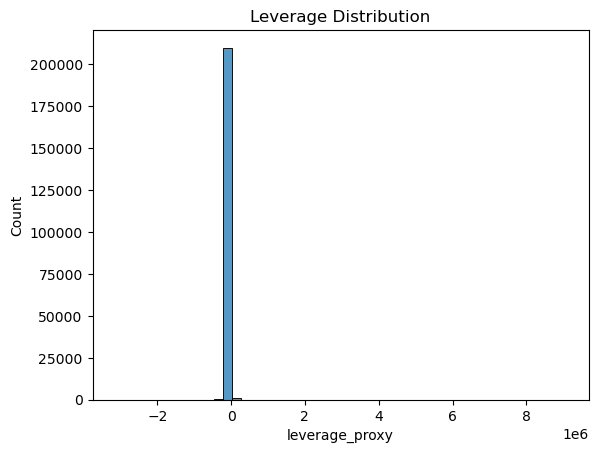

In [46]:
sns.histplot(trades['leverage_proxy'], bins=50)
plt.title("Leverage Distribution")
plt.show()

# Number of Trades per Day

In [47]:
trades_per_day = trades.groupby('date').size().reset_index(name='num_trades')

trades_per_day.head()

,date,num_trades
0,2023-05-01,3
1,2023-12-05,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


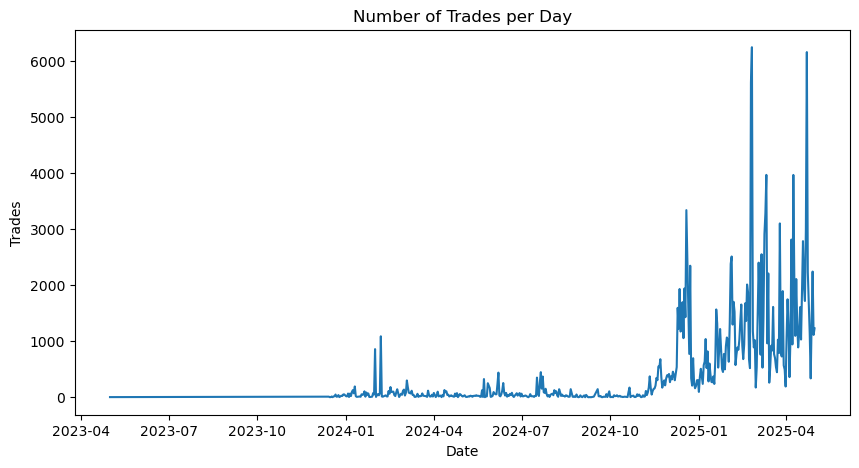

In [48]:
plt.figure(figsize=(10,5))
plt.plot(trades_per_day['date'], trades_per_day['num_trades'])
plt.title("Number of Trades per Day")
plt.xlabel("Date")
plt.ylabel("Trades")
plt.show()

# Long / Short Ratio

In [49]:
long_short = trades.groupby(['date','Direction']).size().unstack().fillna(0)

In [53]:
long_short['long_short_ratio'] = long_short['Buy'] / (long_short['Sell'] + 1)

long_short.head()

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion,long_short_ratio
date,,,,,,,,,,,,,
2023-05-01,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-05,0.0,0.0,0.0,0.0,0.0,0.0,7.0,2.0,0.0,0.0,0.0,0.0,0.0
2023-12-14,0.0,0.0,4.0,2.0,0.0,0.0,3.0,2.0,0.0,0.0,0.0,0.0,0.0
2023-12-15,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2023-12-16,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0


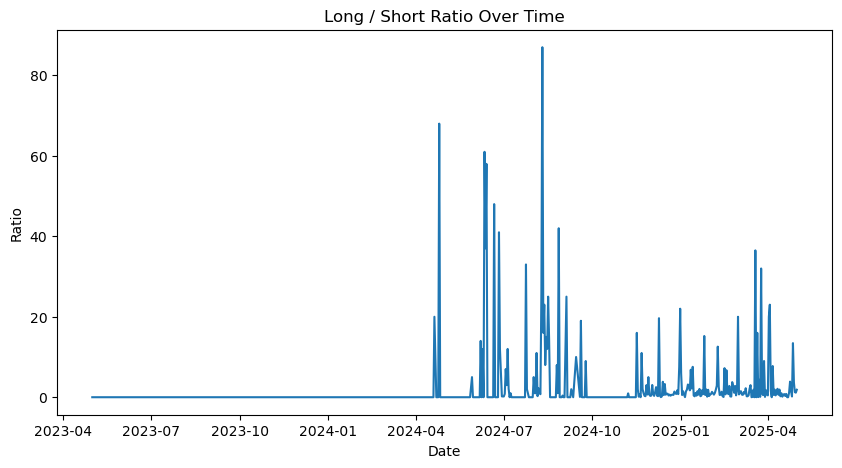

In [55]:
long_short['long_short_ratio'].plot(figsize=(10,5))
plt.title("Long / Short Ratio Over Time")
plt.xlabel("Date")
plt.ylabel("Ratio")
plt.show()

# Merge Datasets

In [56]:
data = trades.merge(
    sentiment[['date','classification']],
    on='date',
    how='left'
)

In [57]:
data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,win,leverage_proxy,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,False,7872.160000,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,False,0.129293,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,False,1.146595,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,False,0.995191,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,False,0.054049,Extreme Greed


# Does performance differ between Fear vs Greed days?

In [58]:
pnl_by_sentiment = data.groupby('classification')['Closed PnL'].mean()
print(pnl_by_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


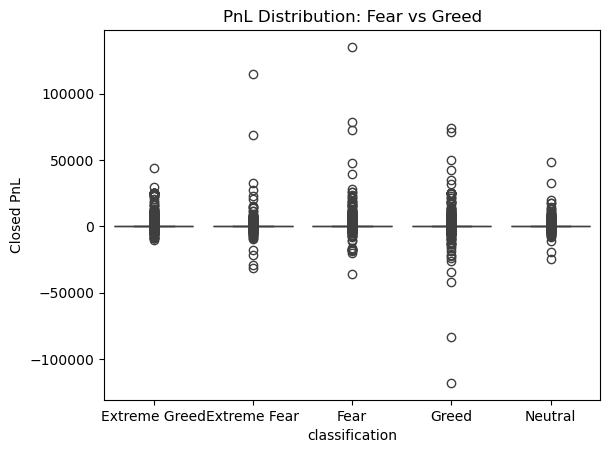

In [59]:
sns.boxplot(x='classification', y='Closed PnL', data=data)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

In [87]:
win_rate = data.groupby('classification')['win'].mean()
print(win_rate)

classification
Extreme Fear     0.370607
Extreme Greed    0.464943
Fear             0.420768
Greed            0.384828
Neutral          0.396991
Name: win, dtype: float64


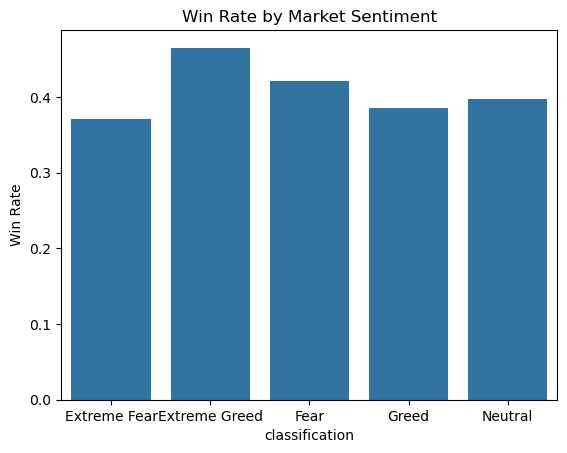

In [88]:
sns.barplot(x=win_rate.index, y=win_rate.values)
plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate")
plt.show()

In [89]:
losses = data[data['Closed PnL'] < 0]

loss_sentiment = losses.groupby('classification')['Closed PnL'].mean()
print(loss_sentiment)

classification
Extreme Fear    -257.099629
Extreme Greed   -119.920289
Fear            -156.662401
Greed           -181.967329
Neutral         -121.727849
Name: Closed PnL, dtype: float64


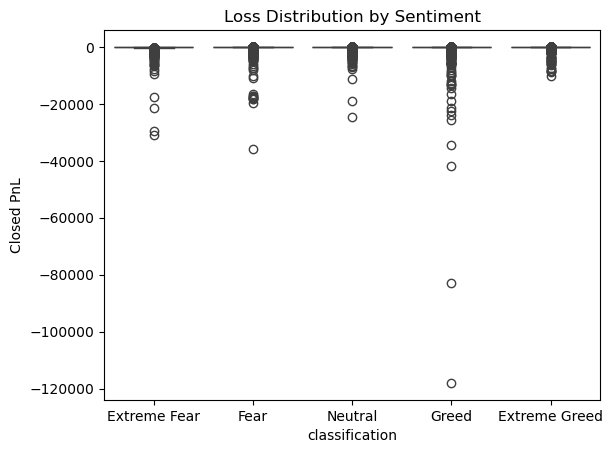

In [90]:
sns.boxplot(x='classification', y='Closed PnL', data=losses)
plt.title("Loss Distribution by Sentiment")
plt.show()

# Do traders change behavior based on sentiment?

In [122]:
trade_frequency = data.groupby(['date','classification']).size().reset_index(name='num_trades')
print(trade_frequency)

           date classification  num_trades
0    2023-05-01          Greed           3
1    2023-12-05  Extreme Greed           9
2    2023-12-14          Greed          11
3    2023-12-15          Greed           2
4    2023-12-16          Greed           3
..          ...            ...         ...
474  2025-04-27          Greed         337
475  2025-04-28        Neutral        1379
476  2025-04-29          Greed        2243
477  2025-04-30          Greed        1113
478  2025-05-01        Neutral        1230

[479 rows x 3 columns]


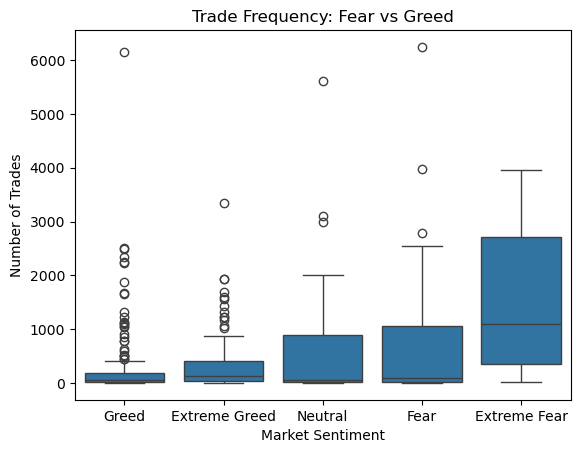

In [71]:
sns.boxplot(x='classification', y='num_trades', data=trade_frequency)
plt.title("Trade Frequency: Fear vs Greed")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")
plt.show()

In [91]:
size_behavior = data.groupby('classification')['Size USD'].mean()
print(size_behavior)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


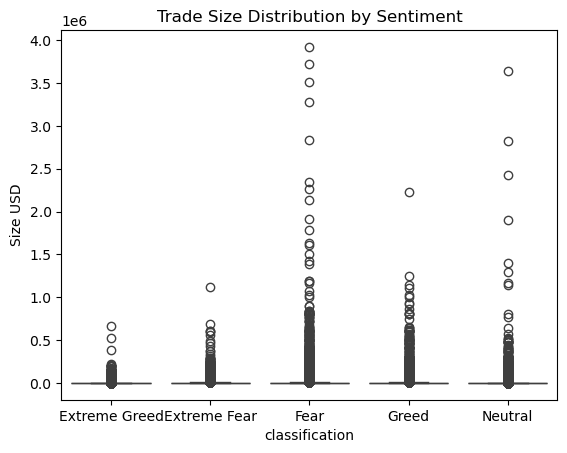

In [92]:
sns.boxplot(x='classification', y='Size USD', data=data)
plt.title("Trade Size Distribution by Sentiment")
plt.show()

In [93]:
bias = data.groupby(['classification','Direction']).size().unstack()
print(bias)

Direction       Auto-Deleveraging     Buy  Close Long  Close Short  \
classification                                                       
Extreme Fear                  NaN   807.0      6241.0       3117.0   
Extreme Greed                 NaN  5132.0      7186.0       6497.0   
Fear                          NaN  3207.0     17260.0       9221.0   
Greed                         8.0  4685.0      7998.0      11322.0   
Neutral                       NaN  2885.0      9993.0       5850.0   

Direction       Liquidated Isolated Short  Long > Short  Open Long  \
classification                                                       
Extreme Fear                          NaN           5.0     7005.0   
Extreme Greed                         NaN           7.0     6300.0   
Fear                                  NaN          14.0    17824.0   
Greed                                 1.0          16.0     8544.0   
Neutral                               NaN          15.0    10222.0   

Direction       Op

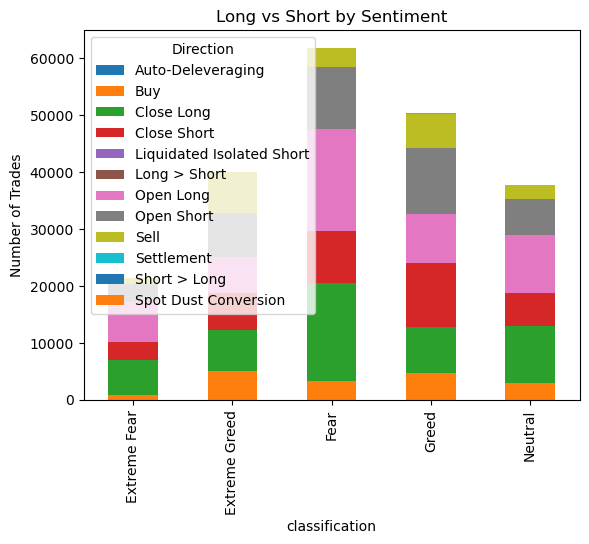

In [94]:
bias.plot(kind='bar', stacked=True)
plt.title("Long vs Short by Sentiment")
plt.ylabel("Number of Trades")
plt.show()

In [95]:
lev_sentiment = data.groupby('classification')['leverage_proxy'].mean()
print(lev_sentiment)

classification
Extreme Fear     inf
Extreme Greed    inf
Fear             inf
Greed            inf
Neutral          inf
Name: leverage_proxy, dtype: float64


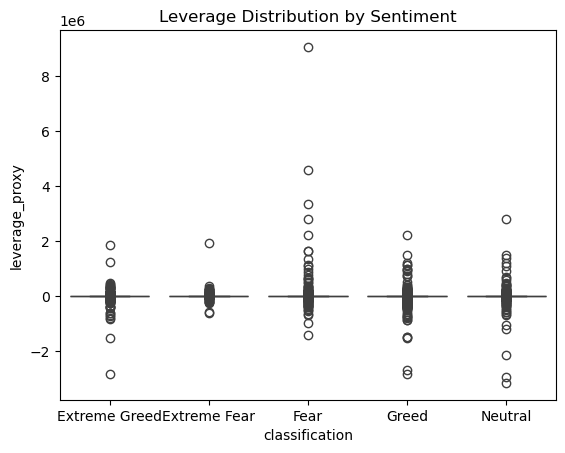

In [96]:
sns.boxplot(x='classification', y='leverage_proxy', data=data)
plt.title("Leverage Distribution by Sentiment")
plt.show()

# Trader Segmentation

In [ ]:
 #High vs Low Leverage Traders

In [108]:
data['leverage_proxy'] = data['Size USD'] / (data['Start Position'] + 1)

In [109]:
median_lev = data['leverage_proxy'].median()

data['leverage_group'] = data['leverage_proxy'].apply(
    lambda x: 'High Leverage' if x > median_lev else 'Low Leverage'
)

In [110]:
leverage_summary = data.groupby('leverage_group').agg(
    avg_pnl=('Closed PnL','mean'),
    win_rate=('win','mean'),
    avg_trade_size=('Size USD','mean'),
    trades=('Account','count')
)

print(leverage_summary)

                  avg_pnl  win_rate  avg_trade_size  trades
leverage_group                                             
High Leverage   58.567772  0.400428     8028.623068  105612
Low Leverage    38.930230  0.422102     3250.279353  105612


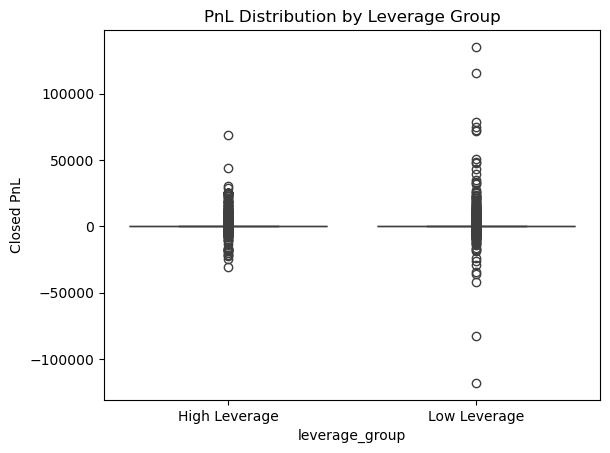

In [111]:
sns.boxplot(x='leverage_group', y='Closed PnL', data=data)
plt.title("PnL Distribution by Leverage Group")
plt.show()

In [ ]:
# Frequent vs Infrequent Traders

In [112]:
trade_counts = data.groupby('Account').size()

In [113]:
data['trader_type'] = data['Account'].apply(
    lambda x: 'Frequent' if trade_counts[x] > threshold else 'Infrequent'
)

In [114]:
freq_summary = data.groupby('trader_type').agg(
    avg_pnl=('Closed PnL','mean'),
    win_rate=('win','mean'),
    avg_trade_size=('Size USD','mean'),
    total_trades=('Account','count')
)

print(freq_summary)

               avg_pnl  win_rate  avg_trade_size  total_trades
trader_type                                                   
Frequent     42.493421  0.415438     5800.826314        186957
Infrequent   96.943024  0.379116     4396.190601         24267


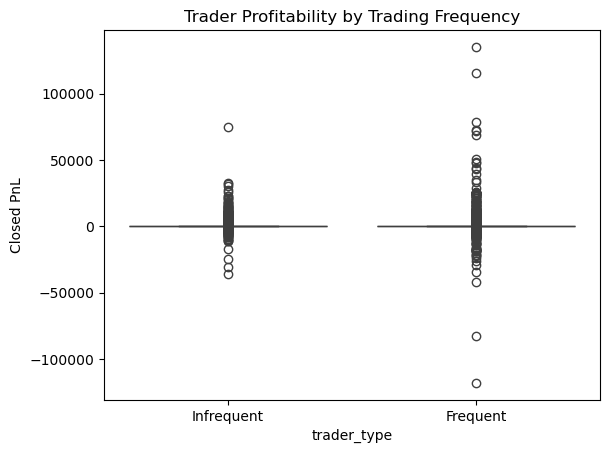

In [115]:
sns.boxplot(x='trader_type', y='Closed PnL', data=data)
plt.title("Trader Profitability by Trading Frequency")
plt.show()

In [106]:
# Consistent Winners vs Inconsistent Traders

In [116]:
trader_pnl = data.groupby('Account')['Closed PnL'].sum()

In [117]:
data['performance_group'] = data['Account'].apply(
    lambda x: 'Consistent Winner' if trader_pnl[x] > 0 else 'Inconsistent'
)

In [118]:
performance_summary = data.groupby('performance_group').agg(
    avg_pnl=('Closed PnL','mean'),
    win_rate=('win','mean'),
    avg_trade_size=('Size USD','mean'),
    trades=('Account','count')
)
print(performance_summary)

                     avg_pnl  win_rate  avg_trade_size  trades
performance_group                                             
Consistent Winner  52.308278  0.413799     5672.108980  201999
Inconsistent      -29.188175  0.355772     4924.346943    9225


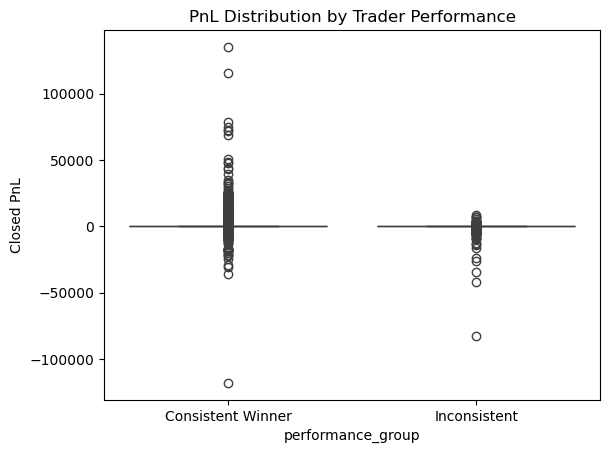

In [119]:
sns.boxplot(x='performance_group', y='Closed PnL', data=data)
plt.title("PnL Distribution by Trader Performance")
plt.show()

# Key Insights

In [123]:
# Insight 1 — Trader losses are highest during Extreme Fear markets
# The analysis of average Closed PnL by sentiment shows that Extreme Fear has the most negative average PnL (~ -257), indicating that traders experience the largest losses during extremely negative market sentiment. This suggests that panic-driven markets are highly volatile and difficult to trade profitably.
# Table/Chart: loss distribution by Sentiment

# Insight 2 — Win rates improve during positive market sentiment
# The win rate analysis shows that Extreme Greed has the highest win rate (~46%), while Extreme Fear has the lowest (~37%). This indicates that traders tend to perform better when the market sentiment is strongly positive.
# Table/Chart: Win Rate by Sentiment

# Insight 3 — Trade sizes change depending on market sentiment
# The average trade size varies across sentiment levels. The largest average trade size occurs during Fear (~7816 USD), suggesting traders may take larger positions when attempting to capture price rebounds during declining markets.
# Table/Chart: Trade Size distribution by Sentiment

# Actionable output

In [124]:
# Strategy 1 — Risk Reduction During Fear Markets
# During Fear sentiment periods:
#- Reduce leverage exposure
#- Reduce position sizes
#- Avoid excessive trading
# Reason:
# These periods show higher losses and lower win rates, indicating higher market uncertainty and risk.

# Strategy 2 — Momentum Strategy During Greed Markets
# During Greed sentiment periods:
#- Favor long positions
#- Increase trade frequency moderately
#- Capitalize on bullish momentum
# Reason:
# These periods show higher win rates and more favorable trading conditions, suggesting stronger and more predictable market trends.